In [76]:
import json
import pandas as pd
import matplotlib.pyplot as plt


def read_jsonl(path: str) -> pd.DataFrame:
    with open(path) as f:
        records = [json.loads(line) for line in f if line.strip()]
    return pd.DataFrame(records)


STRATEGIES = [
    "SAVINGS",
    "PATH_CHEAPEST_ARC",
    "SAVINGS_TABU_SEARCH",
    "PATH_CHEAPEST_ARC_TABU_SEARCH",
    "SAVINGS_GUIDED_LOCAL_SEARCH",
    "PATH_CHEAPEST_ARC_GUIDED_LOCAL_SEARCH",
]
COUNTS = [20, 50, 100]

frames = []
for strategy in STRATEGIES:
    for dynamic in (False, True):
        for n in COUNTS:
            kind = "dynamic" if dynamic else "static"
            df = read_jsonl(f"{strategy}/{strategy}_{kind}_{n}.jsonl")
            df = df[df["all_orders_delivered"]]
            df["strategy"] = strategy
            df["dynamic"] = dynamic
            frames.append(df)

all_runs = pd.concat(frames, ignore_index=True)

all_runs.head()


,timestamp,seed,replication_index,num_static_customers,num_dynamic_events,min_event_time,max_event_time,num_vehicles,num_orders_delivered,num_orders_total,all_orders_delivered,jain_fairness_index,total_makespan,truck_delivery_times,solve_times,reassigning_rates,strategy,dynamic
0,2026-07-29T09:46:33,0,0,20,4,0,0,4,24,24,True,0.499998,29356.084733,"{'TRUCK-2': 29356.08473348482, 'TRUCK-1': 29250.654499225846}",[0.07782662499812432],[],SAVINGS,False
1,2026-07-29T09:46:33,1,1,20,4,0,0,4,24,24,True,0.963054,15095.957777,"{'TRUCK-3': 8794.049485547795, 'TRUCK-1': 13491.108617930431, 'TRUCK-4': 15009.680662599898, 'TRUCK-2': 15095.957777097115}",[0.12786399998003617],[],SAVINGS,False
2,2026-07-29T09:46:33,2,2,20,4,0,0,4,24,24,True,0.976162,15029.915157,"{'TRUCK-3': 15029.915156875442, 'TRUCK-4': 14492.78791647285, 'TRUCK-2': 9785.743158184852, 'TRUCK-1': 14123.139830514425}",[0.06715200000326149],[],SAVINGS,False
3,2026-07-29T09:46:33,3,3,20,4,0,0,4,24,24,True,0.967315,14560.134324,"{'TRUCK-1': 14472.470114276362, 'TRUCK-3': 14560.134323736178, 'TRUCK-4': 9083.0535783013, 'TRUCK-2': 11491.77941947363}",[0.049538208986632526],[],SAVINGS,False
4,2026-07-29T09:46:33,4,4,20,4,0,0,4,24,24,True,0.740904,18158.212517,"{'TRUCK-1': 18158.21251700565, 'TRUCK-2': 17655.411309059706, 'TRUCK-3': 14026.310035385492}",[0.027437125012511387],[],SAVINGS,False


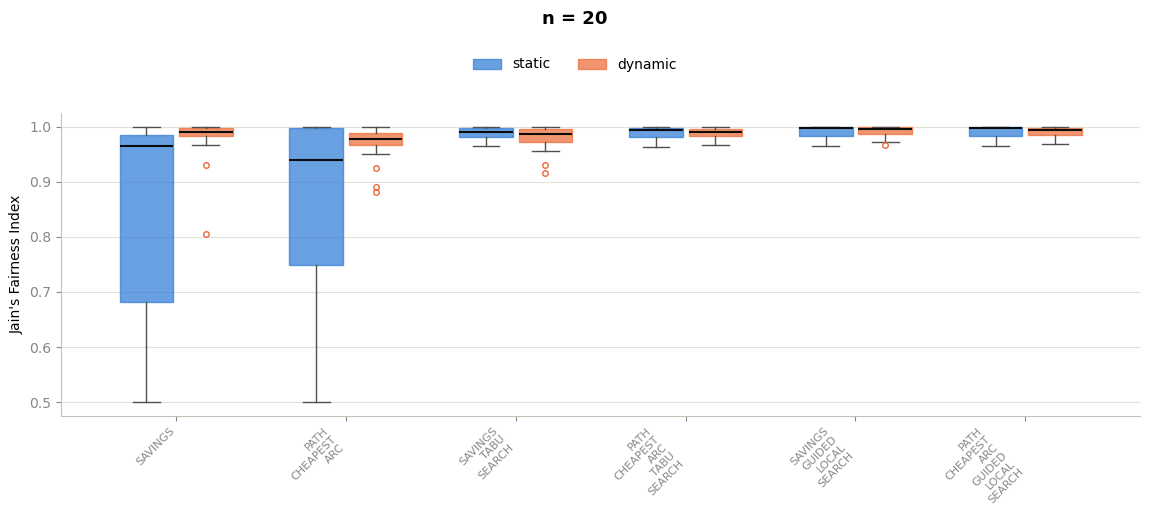

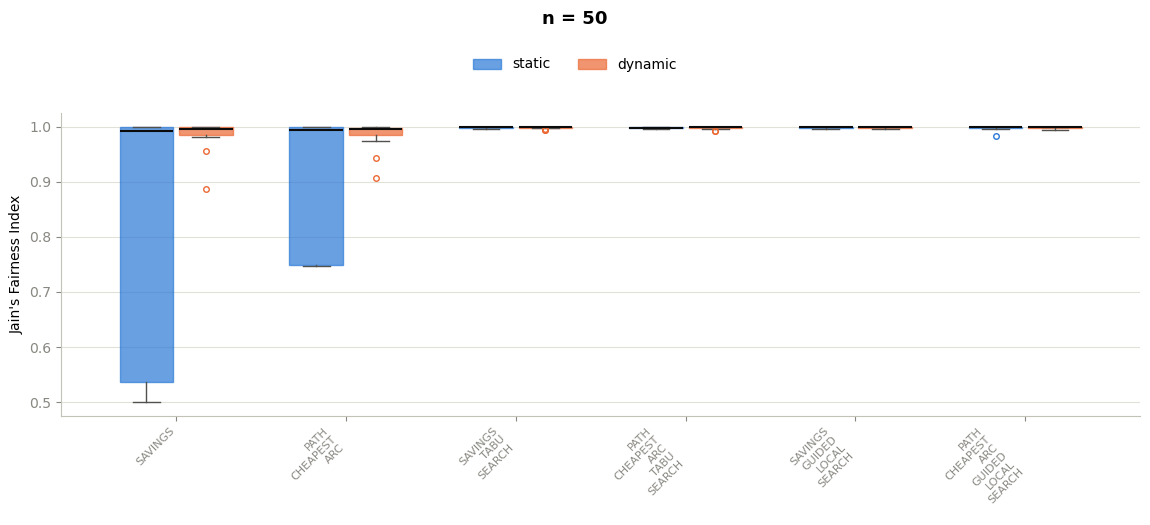

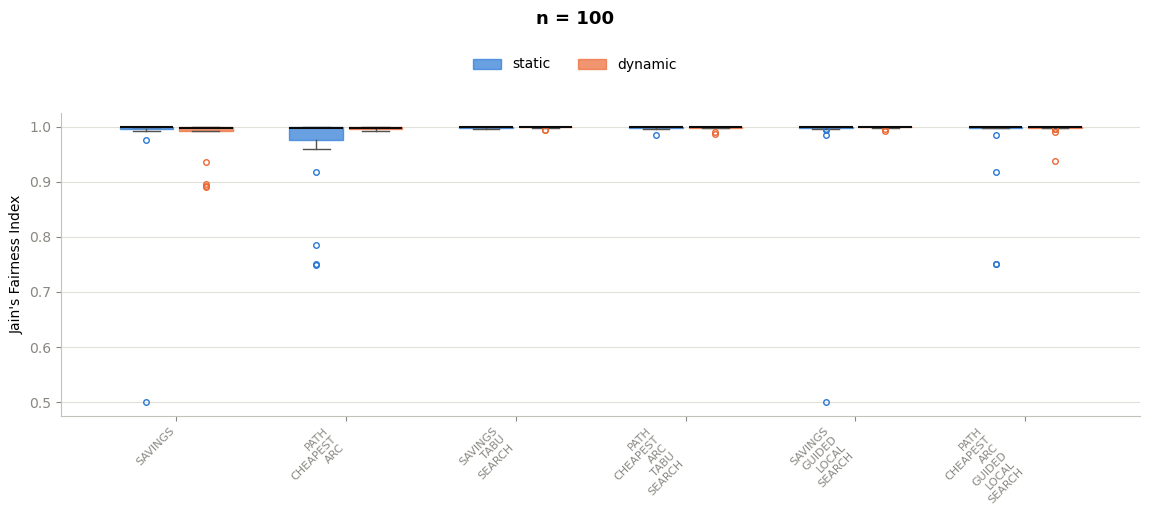

In [77]:
import numpy as np

width = 0.35
colors = {"static": "#2a78d6", "dynamic": "#eb6834"}


def _boxplot_style(color):
    return dict(
        patch_artist=True,
        medianprops={"color": "#0b0b0b", "linewidth": 1.5},
        boxprops={"facecolor": color, "edgecolor": color, "alpha": 0.7},
        whiskerprops={"color": "#52514e"},
        capprops={"color": "#52514e"},
        flierprops={"markeredgecolor": color, "markersize": 4},
    )


def _style_axis(ax):
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color("#c3c2b7")
    ax.tick_params(colors="#898781")
    ax.yaxis.grid(True, color="#e1e0d9", linewidth=0.8)
    ax.set_axisbelow(True)


def _annotate_center(ax, values, center="mean", fmt="{:.2f}"):
    value = values.mean() if center == "mean" else values.median()
    ax.axvline(value, color="#0b0b0b", linestyle="--", linewidth=1.2)
    ax.text(
        value,
        0.95,
        fmt.format(value),
        transform=ax.get_xaxis_transform(),
        rotation=90,
        va="top",
        ha="right",
        fontsize=6,
        color="#0b0b0b",
    )


def plot_metric_by_strategy(data, value_col, ylabel, log=False, counts=COUNTS):
    strategy_labels = [s.replace("_", "\n") for s in STRATEGIES]
    x = np.arange(len(STRATEGIES))
    fig_width = max(10, 1.6 * len(STRATEGIES) + 2)

    for n in counts:
        subset = data[data["num_static_customers"] == n]
        static_data = [
            subset[(subset["strategy"] == s) & (~subset["dynamic"])][value_col]
            for s in STRATEGIES
        ]
        dynamic_data = [
            subset[(subset["strategy"] == s) & (subset["dynamic"])][value_col]
            for s in STRATEGIES
        ]

        fig, ax = plt.subplots(figsize=(fig_width, 5))

        bp_static = ax.boxplot(
            static_data,
            positions=x - width / 2,
            widths=width * 0.9,
            **_boxplot_style(colors["static"]),
        )
        bp_dynamic = ax.boxplot(
            dynamic_data,
            positions=x + width / 2,
            widths=width * 0.9,
            **_boxplot_style(colors["dynamic"]),
        )

        ax.set_xticks(x)
        ax.set_xticklabels(strategy_labels, rotation=45, ha="right", fontsize=8)
        if log:
            ax.set_yscale("log")
        ax.set_ylabel(ylabel)
        _style_axis(ax)

        fig.suptitle(f"n = {n}", y=1.04, fontsize=13, fontweight="bold")
        fig.legend(
            [bp_static["boxes"][0], bp_dynamic["boxes"][0]],
            ["static", "dynamic"],
            loc="upper center",
            bbox_to_anchor=(0.5, 0.97),
            ncol=2,
            frameon=False,
        )

        plt.tight_layout(rect=[0, 0, 1, 0.93])
        plt.show()


def plot_metric_by_strategy_split(data, value_col, ylabel, log=False, counts=COUNTS):
    strategy_labels = [s.replace("_", "\n") for s in STRATEGIES]
    x = np.arange(len(STRATEGIES))
    fig_width = max(10, 1.6 * len(STRATEGIES) + 2)

    for n in counts:
        subset = data[data["num_static_customers"] == n]
        for dynamic, kind in ((False, "static"), (True, "dynamic")):
            kind_data = [
                subset[(subset["strategy"] == s) & (subset["dynamic"] == dynamic)][value_col]
                for s in STRATEGIES
            ]

            fig, ax = plt.subplots(figsize=(fig_width, 5))

            ax.boxplot(
                kind_data,
                positions=x,
                widths=0.6,
                **_boxplot_style(colors[kind]),
            )

            ax.set_xticks(x)
            ax.set_xticklabels(strategy_labels, rotation=45, ha="right", fontsize=8)
            if log:
                ax.set_yscale("log")
            ax.set_ylabel(ylabel)
            _style_axis(ax)

            fig.suptitle(f"{ylabel} — {kind} — n = {n}", y=1.02, fontsize=13, fontweight="bold")
            plt.tight_layout(rect=[0, 0, 1, 0.93])
            plt.show()


plot_metric_by_strategy(all_runs, "jain_fairness_index", "Jain's Fairness Index")


In [78]:
summary = (
    all_runs.assign(kind=all_runs["dynamic"].map({False: "static", True: "dynamic"}))
    .groupby(["strategy", "kind", "num_static_customers"])["jain_fairness_index"]
    .agg(["mean", "median", "std", "min", "max"])
    .round(3)
)
summary


mean  \
strategy                              kind    num_static_customers          
PATH_CHEAPEST_ARC                     dynamic 20                    0.969   
                                              50                    0.986   
                                              100                   0.998   
                                      static  20                    0.861   
                                              50                    0.910   
                                              100                   0.955   
PATH_CHEAPEST_ARC_GUIDED_LOCAL_SEARCH dynamic 20                    0.990   
                                              50                    0.998   
                                              100                   0.995   
                                      static  20                    0.989   
                                              50                    0.998   
                                              100                   0.970   
PATH_CHEAPEST_ARC_TABU_SEARCH         dynamic 20                    0.988   
                                              50                    0.998   
                                              100                   0.998   
                                      static  20                    0.988   
                                              50                    0.998   
                                              100                   0.998   
SAVINGS                               dynamic 20                    0.976   
                                              50                    0.986   
                                              100                   0.977   
                                      static  20                    0.816   
                                              50                    0.813   
                                              100                   0.972   
SAVINGS_GUIDED_LOCAL_SEARCH           dynamic 20                    0.992   
                                              50                    0.999   
                                              100                   0.999   
                                      static  20                    0.989   
                                              50                    0.999   
                                              100                   0.973   
SAVINGS_TABU_SEARCH                   dynamic 20                    0.980   
                                              50                    0.998   
                                              100                   0.999   
                                      static  20                    0.987   
                                              50                    0.998   
                                              100                   0.999   

                                                                    median  \
strategy                              kind    num_static_customers           
PATH_CHEAPEST_ARC                     dynamic 20                     0.977   
                                              50                     0.997   
                                              100                    0.998   
                                      static  20                     0.940   
                                              50                     0.994   
                                              100                    0.998   
PATH_CHEAPEST_ARC_GUIDED_LOCAL_SEARCH dynamic 20                     0.994   
                                              50                     0.999   
                                              100                    0.999   
                                      static  20                     0.997   
                                              50                     0.999   
                                              100                    1.000   
PATH_CHEAPEST_ARC_TABU_SEARCH         dynamic 20  

In [79]:
pd.set_option("display.max_colwidth", None)

all_runs["total_distance"] = all_runs["truck_delivery_times"].apply(lambda d: sum(d.values()))

all_runs[["strategy", "dynamic", "num_static_customers", "total_makespan", "truck_delivery_times","total_distance"]].head()


,strategy,dynamic,num_static_customers,total_makespan,truck_delivery_times,total_distance
0,SAVINGS,False,20,29356.084733,"{'TRUCK-2': 29356.08473348482, 'TRUCK-1': 29250.654499225846}",58606.739233
1,SAVINGS,False,20,15095.957777,"{'TRUCK-3': 8794.049485547795, 'TRUCK-1': 13491.108617930431, 'TRUCK-4': 15009.680662599898, 'TRUCK-2': 15095.957777097115}",52390.796543
2,SAVINGS,False,20,15029.915157,"{'TRUCK-3': 15029.915156875442, 'TRUCK-4': 14492.78791647285, 'TRUCK-2': 9785.743158184852, 'TRUCK-1': 14123.139830514425}",53431.586062
3,SAVINGS,False,20,14560.134324,"{'TRUCK-1': 14472.470114276362, 'TRUCK-3': 14560.134323736178, 'TRUCK-4': 9083.0535783013, 'TRUCK-2': 11491.77941947363}",49607.437436
4,SAVINGS,False,20,18158.212517,"{'TRUCK-1': 18158.21251700565, 'TRUCK-2': 17655.411309059706, 'TRUCK-3': 14026.310035385492}",49839.933861


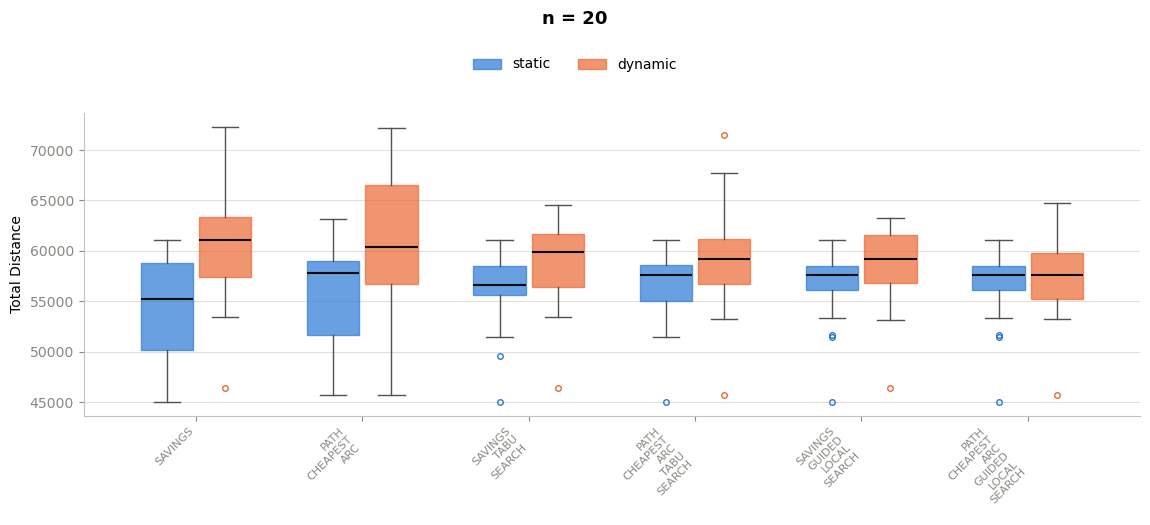

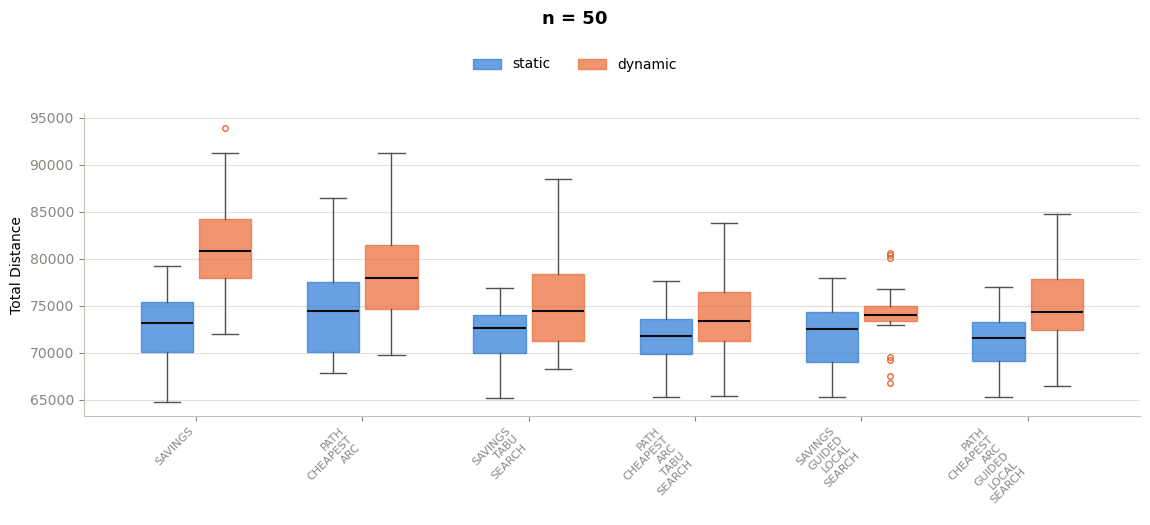

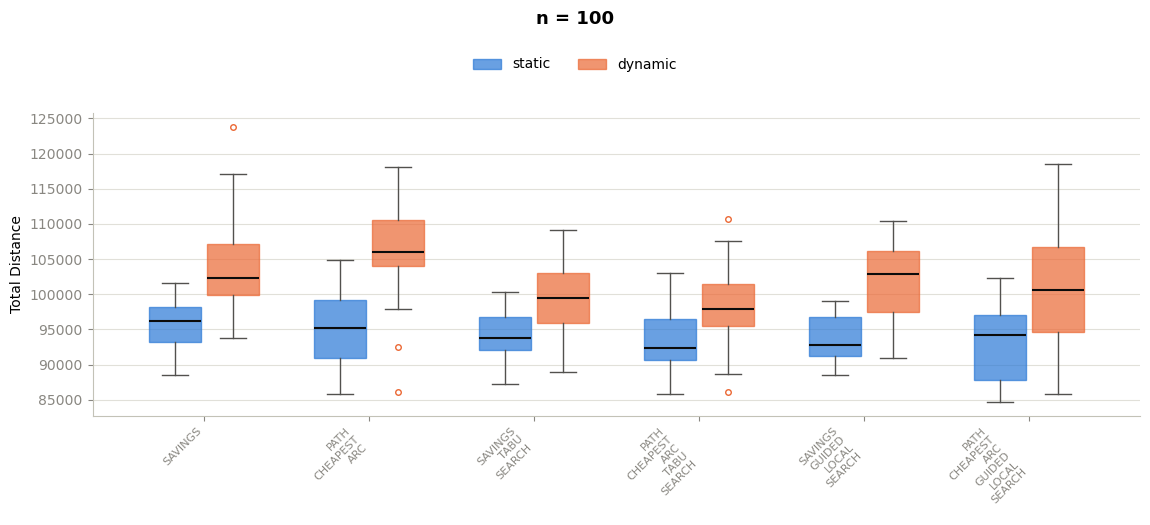

In [80]:
plot_metric_by_strategy(all_runs, "total_distance", "Total Distance")


In [81]:
iqr_summary = (
    all_runs.assign(kind=all_runs["dynamic"].map({False: "static", True: "dynamic"}))
    .groupby(["strategy", "kind", "num_static_customers"])["total_distance"]
    .apply(lambda s: s.quantile(0.75) - s.quantile(0.25))
    .rename("iqr")
)
iqr_summary.round(1)


strategy                               kind     num_static_customers
PATH_CHEAPEST_ARC                      dynamic  20                       9857.7
                                                50                       6828.4
                                                100                      6616.0
                                       static   20                       7377.3
                                                50                       7443.9
                                                100                      8162.1
PATH_CHEAPEST_ARC_GUIDED_LOCAL_SEARCH  dynamic  20                       4588.0
                                                50                       5435.8
                                                100                     12164.7
                                       static   20                       2364.1
                                                50                       4189.0
                                                100

In [82]:
iqr_comparison = iqr_summary.unstack("kind")
iqr_comparison["pct_diff_dynamic_vs_static"] = (
    (iqr_comparison["dynamic"] - iqr_comparison["static"]) / iqr_comparison["static"] * 100
)
iqr_comparison.round(1)


kind                                                        dynamic  static  \
strategy                              num_static_customers                    
PATH_CHEAPEST_ARC                     20                     9857.7  7377.3   
                                      50                     6828.4  7443.9   
                                      100                    6616.0  8162.1   
PATH_CHEAPEST_ARC_GUIDED_LOCAL_SEARCH 20                     4588.0  2364.1   
                                      50                     5435.8  4189.0   
                                      100                   12164.7  9213.7   
PATH_CHEAPEST_ARC_TABU_SEARCH         20                     4506.4  3568.1   
                                      50                     5174.2  3780.8   
                                      100                    5956.3  5702.4   
SAVINGS                               20                     5951.2  8599.4   
                                      50                     6260.4  5333.4   
                                      100                    7272.2  4941.3   
SAVINGS_GUIDED_LOCAL_SEARCH           20                     4794.7  2364.1   
                                      50                     1555.9  5298.7   
                                      100                    8665.9  5494.2   
SAVINGS_TABU_SEARCH                   20                     5250.4  2909.5   
                                      50                     7164.7  3980.5   
                                      100                    7087.6  4754.8   

kind                                                        pct_diff_dynamic_vs_static  
strategy                              num_static_customers                              
PATH_CHEAPEST_ARC                     20                                          33.6  
                                      50                                          -8.3  
                                      100                                        -18.9  
PATH_CHEAPEST_ARC_GUIDED_LOCAL_SEARCH 20                                          94.1  
                                      50                                          29.8  
                                      100                                         32.0  
PATH_CHEAPEST_ARC_TABU_SEARCH         20                                          26.3  
                                      50                                          36.9  
                                      100                                          4.5  
SAVINGS                               20                                         -30.8  
                                      50                                          17.4  
                                      100                                         47.2  
SAVINGS_GUIDED_LOCAL_SEARCH           20                                         102.8  
                                      50                                         -70.6  
                                      100                                         57.7  
SAVINGS_TABU_SEARCH                   20                                          80.5  
                                      50                                          80.0  
                                      100                                         49.1

In [83]:
median_comparison = (
    all_runs.assign(kind=all_runs["dynamic"].map({False: "static", True: "dynamic"}))
    .groupby(["strategy", "kind", "num_static_customers"])["total_distance"]
    .median()
    .unstack("kind")
)
median_comparison["pct_diff_dynamic_vs_static"] = (
    (median_comparison["dynamic"] - median_comparison["static"]) / median_comparison["static"] * 100
)
median_comparison.round(1)


kind                                                         dynamic   static  \
strategy                              num_static_customers                      
PATH_CHEAPEST_ARC                     20                     60420.4  57828.1   
                                      50                     78009.0  74412.9   
                                      100                   105953.1  95182.5   
PATH_CHEAPEST_ARC_GUIDED_LOCAL_SEARCH 20                     57586.2  57585.4   
                                      50                     74323.3  71545.6   
                                      100                   100664.1  94170.3   
PATH_CHEAPEST_ARC_TABU_SEARCH         20                     59154.8  57585.4   
                                      50                     73395.6  71831.2   
                                      100                    97943.7  92349.8   
SAVINGS                               20                     61113.1  55188.2   
                                      50                     80803.6  73126.6   
                                      100                   102287.7  96171.6   
SAVINGS_GUIDED_LOCAL_SEARCH           20                     59193.6  57585.4   
                                      50                     74072.8  72509.4   
                                      100                   102929.7  92723.5   
SAVINGS_TABU_SEARCH                   20                     59856.7  56652.8   
                                      50                     74487.4  72631.9   
                                      100                    99513.0  93716.0   

kind                                                        pct_diff_dynamic_vs_static  
strategy                              num_static_customers                              
PATH_CHEAPEST_ARC                     20                                           4.5  
                                      50                                           4.8  
                                      100                                         11.3  
PATH_CHEAPEST_ARC_GUIDED_LOCAL_SEARCH 20                                           0.0  
                                      50                                           3.9  
                                      100                                          6.9  
PATH_CHEAPEST_ARC_TABU_SEARCH         20                                           2.7  
                                      50                                           2.2  
                                      100                                          6.1  
SAVINGS                               20                                          10.7  
                                      50                                          10.5  
                                      100                                          6.4  
SAVINGS_GUIDED_LOCAL_SEARCH           20                                           2.8  
                                      50                                           2.2  
                                      100                                         11.0  
SAVINGS_TABU_SEARCH                   20                                           5.7  
                                      50                                           2.6  
                                      100                                          6.2

In [84]:
median_comparison["pct_diff_dynamic_vs_static"].groupby("num_static_customers").mean().round(1)


num_static_customers
20     4.4
50     4.4
100    8.0
Name: pct_diff_dynamic_vs_static, dtype: float64

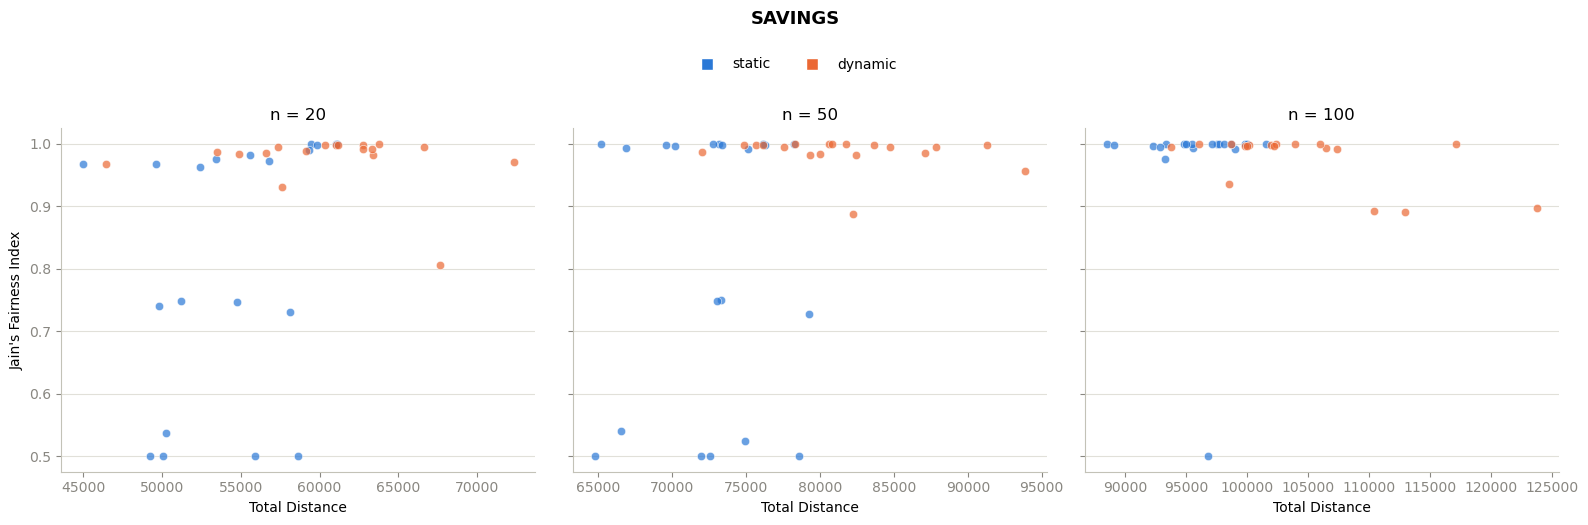

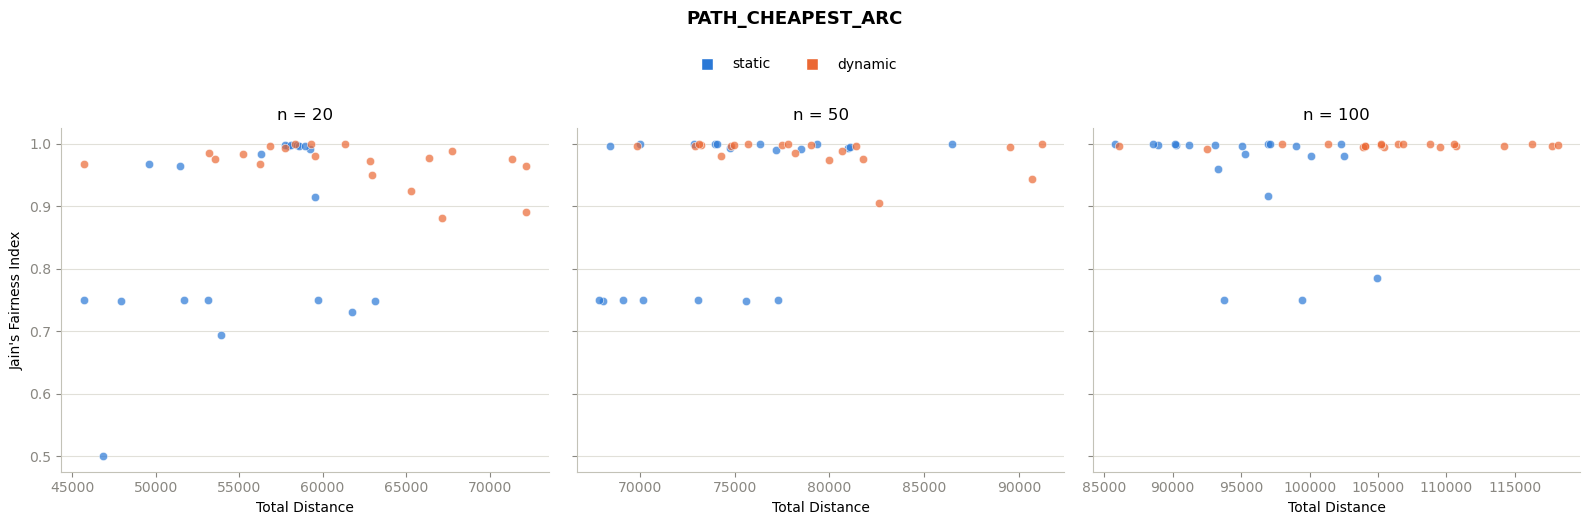

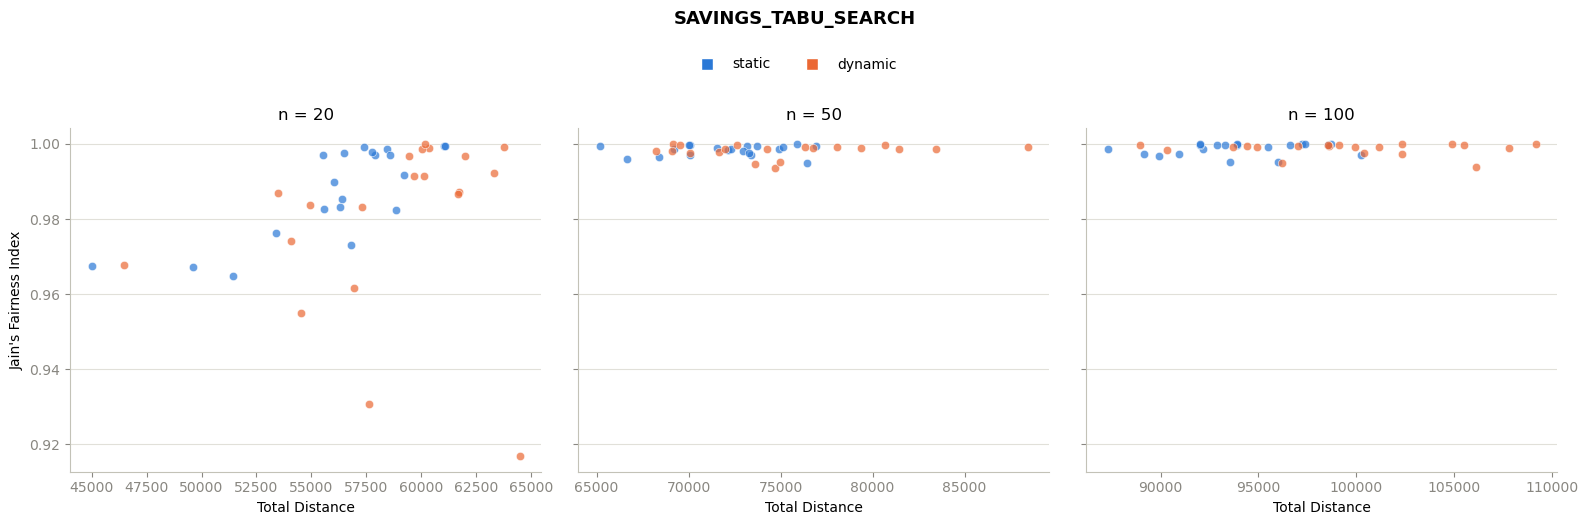

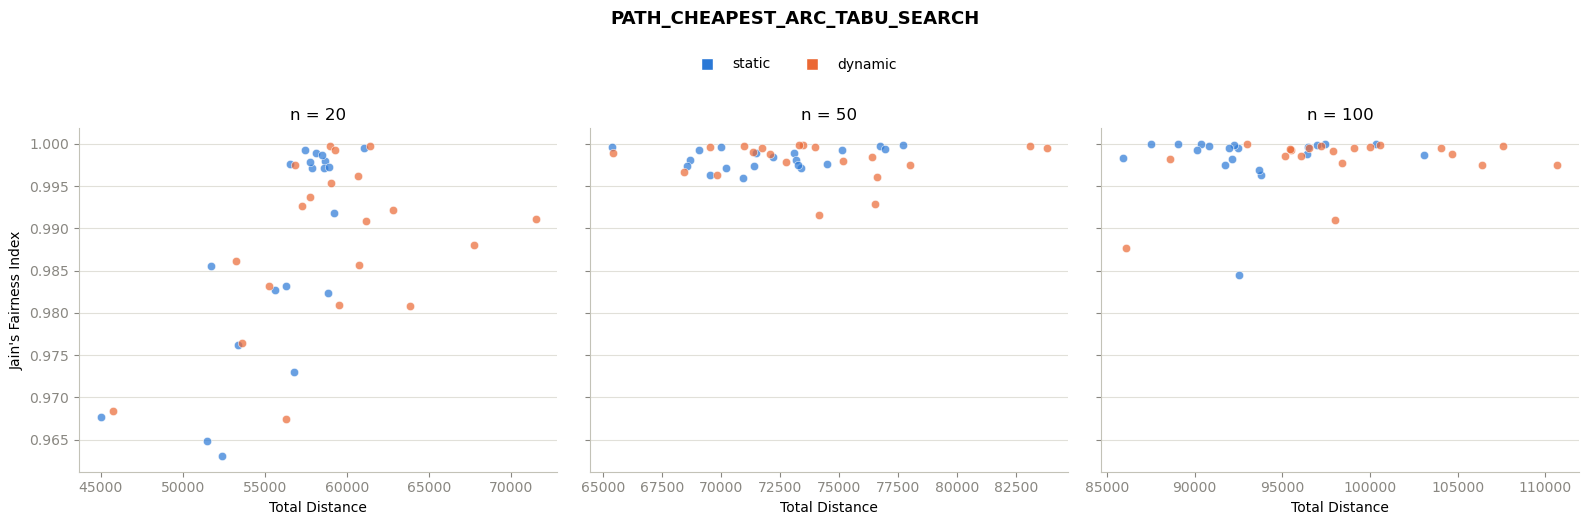

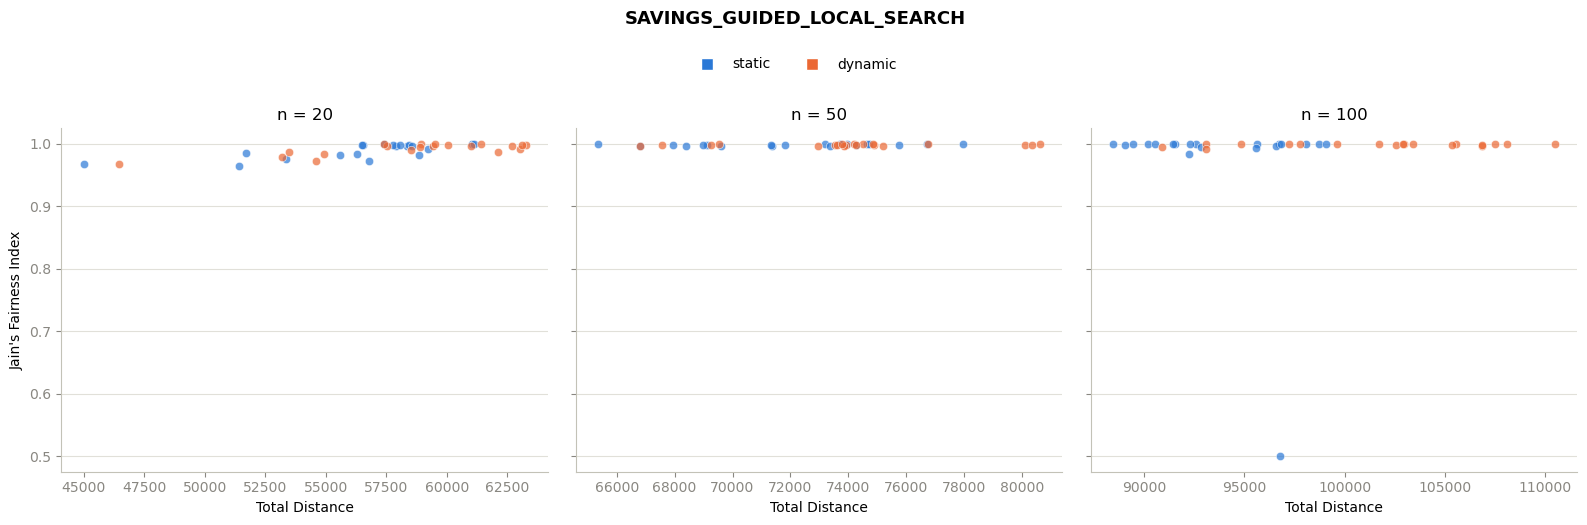

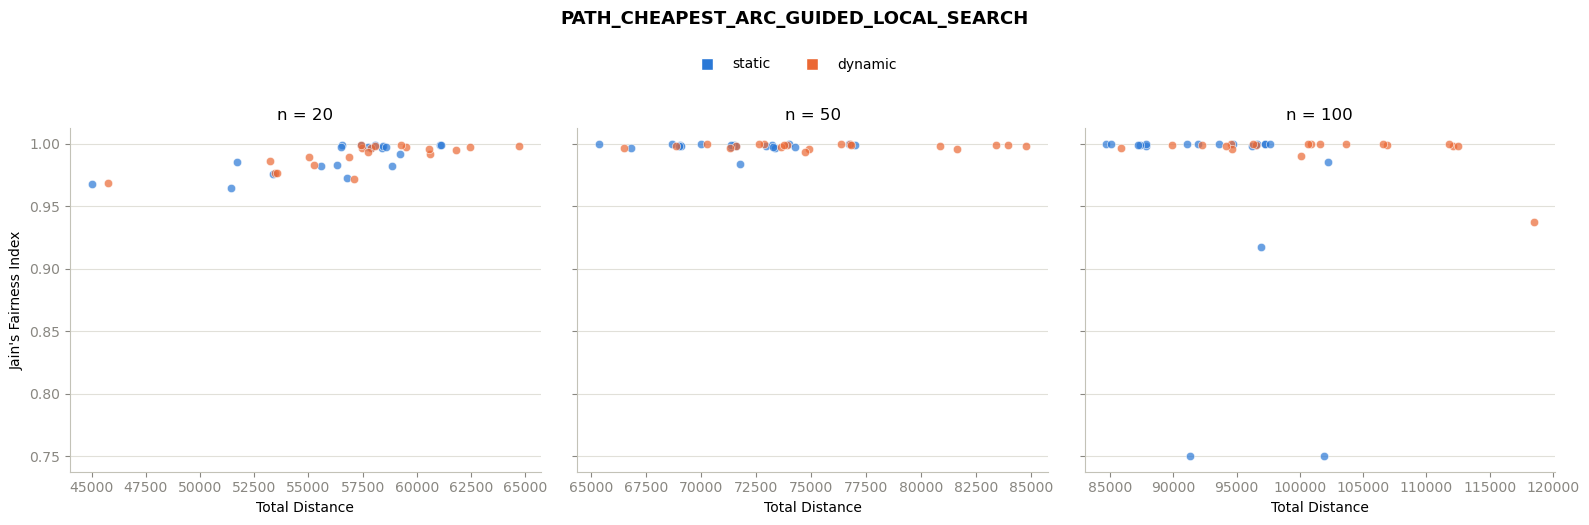

In [85]:
def plot_fairness_vs_distance(strategy):
    fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

    for ax, n in zip(axes, COUNTS):
        subset = all_runs[(all_runs["num_static_customers"] == n) & (all_runs["strategy"] == strategy)]
        for dynamic, kind in ((False, "static"), (True, "dynamic")):
            group = subset[subset["dynamic"] == dynamic]
            ax.scatter(
                group["total_distance"],
                group["jain_fairness_index"],
                color=colors[kind],
                alpha=0.7,
                edgecolor="white",
                linewidth=0.5,
            )
        ax.set_title(f"n = {n}")
        ax.set_xlabel("Total Distance")
        ax.spines[["top", "right"]].set_visible(False)
        ax.spines[["left", "bottom"]].set_color("#c3c2b7")
        ax.tick_params(colors="#898781")
        ax.yaxis.grid(True, color="#e1e0d9", linewidth=0.8)
        ax.set_axisbelow(True)

    axes[0].set_ylabel("Jain's Fairness Index")

    fig.suptitle(strategy, y=1.04, fontsize=13, fontweight="bold")

    color_handles = [
        plt.Line2D([0], [0], marker="s", color="w", markerfacecolor=colors[k], markersize=8, label=k)
        for k in ("static", "dynamic")
    ]
    fig.legend(
        handles=color_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.97),
        ncol=2,
        frameon=False,
    )

    plt.tight_layout(rect=[0, 0, 1, 0.94])
    plt.show()


for strategy in STRATEGIES:
    plot_fairness_vs_distance(strategy)


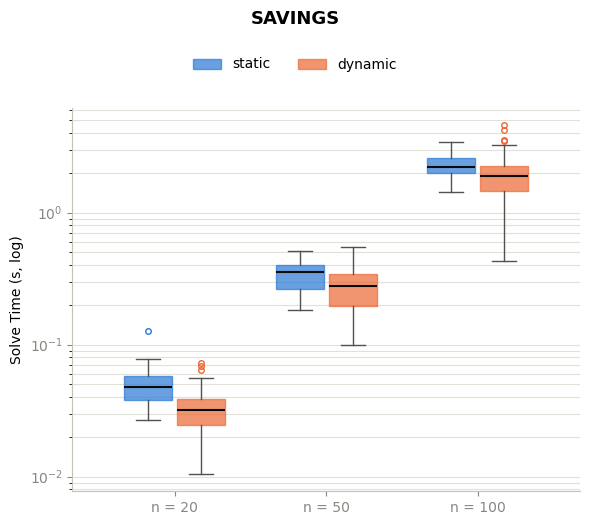

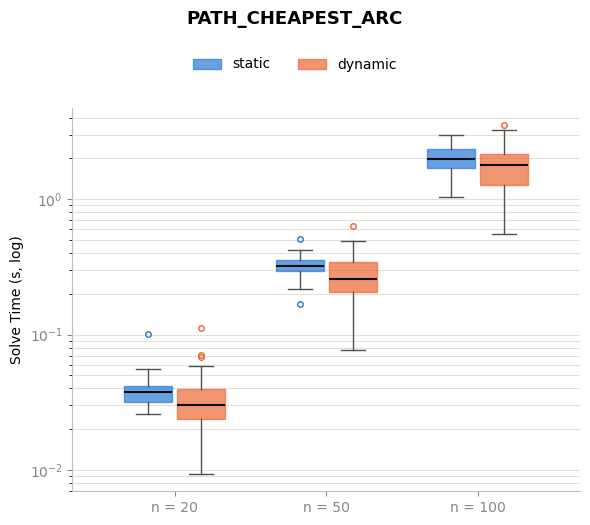

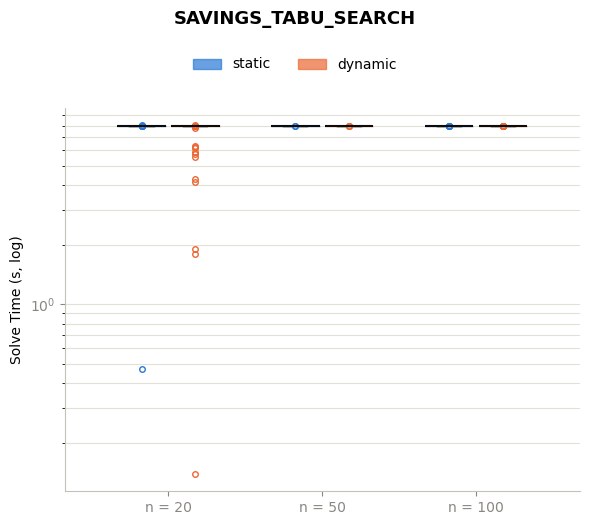

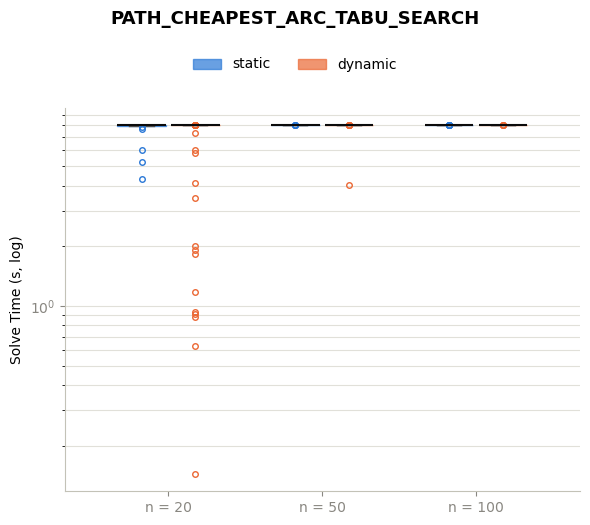

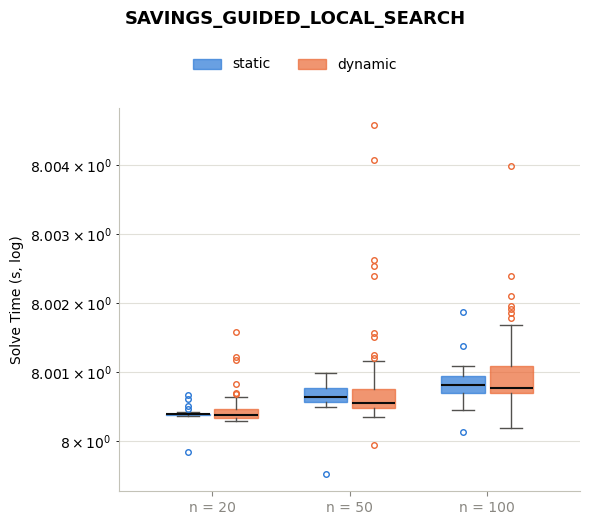

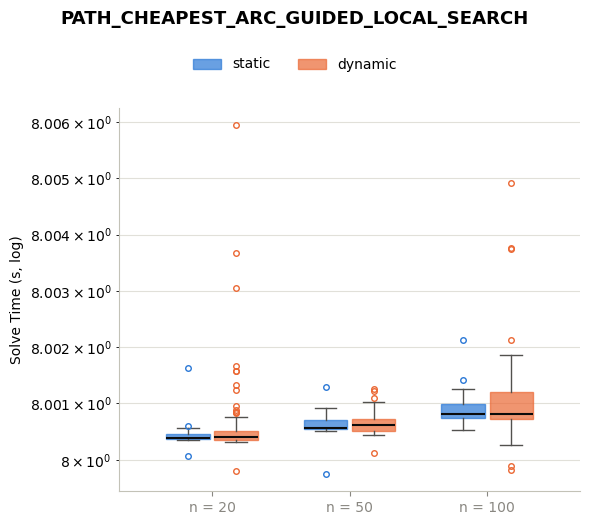

In [86]:
solve_times_df = (
    all_runs[["strategy", "dynamic", "num_static_customers", "solve_times"]]
    .explode("solve_times")
    .rename(columns={"solve_times": "solve_time"})
)
solve_times_df["solve_time"] = solve_times_df["solve_time"].astype(float)


def plot_solve_times_group(strategy):
    x = np.arange(len(COUNTS))

    fig, ax = plt.subplots(figsize=(6, 5))

    subset = solve_times_df[solve_times_df["strategy"] == strategy]
    static_data = [
        subset[(subset["num_static_customers"] == n) & (~subset["dynamic"])]["solve_time"]
        for n in COUNTS
    ]
    dynamic_data = [
        subset[(subset["num_static_customers"] == n) & (subset["dynamic"])]["solve_time"]
        for n in COUNTS
    ]

    bp_static = ax.boxplot(
        static_data,
        positions=x - width / 2,
        widths=width * 0.9,
        **_boxplot_style(colors["static"]),
    )
    bp_dynamic = ax.boxplot(
        dynamic_data,
        positions=x + width / 2,
        widths=width * 0.9,
        **_boxplot_style(colors["dynamic"]),
    )

    ax.set_xticks(x)
    ax.set_xticklabels([f"n = {n}" for n in COUNTS])
    ax.set_yscale("log")
    ax.set_ylabel("Solve Time (s, log)")
    _style_axis(ax)
    ax.yaxis.grid(True, which="both", color="#e1e0d9", linewidth=0.8)

    fig.suptitle(strategy, y=1.04, fontsize=13, fontweight="bold")

    fig.legend(
        [bp_static["boxes"][0], bp_dynamic["boxes"][0]],
        ["static", "dynamic"],
        loc="upper center",
        bbox_to_anchor=(0.5, 0.97),
        ncol=2,
        frameon=False,
    )

    plt.tight_layout(rect=[0, 0, 1, 0.94])
    plt.show()


for strategy in STRATEGIES:
    plot_solve_times_group(strategy)


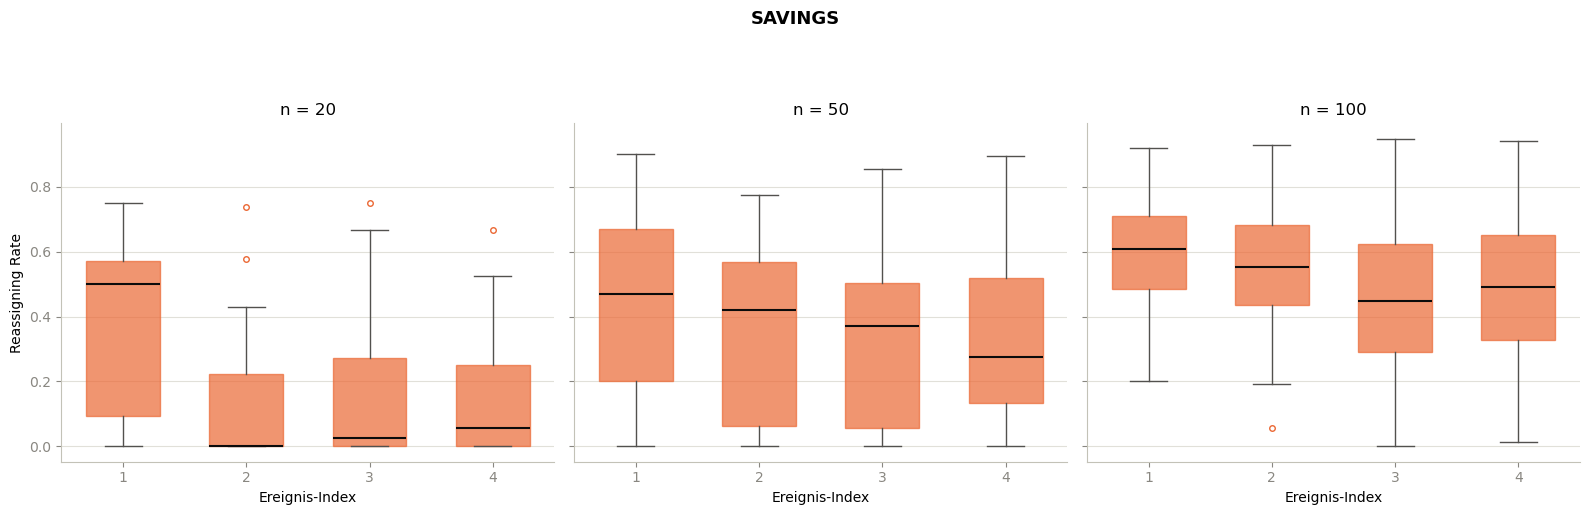

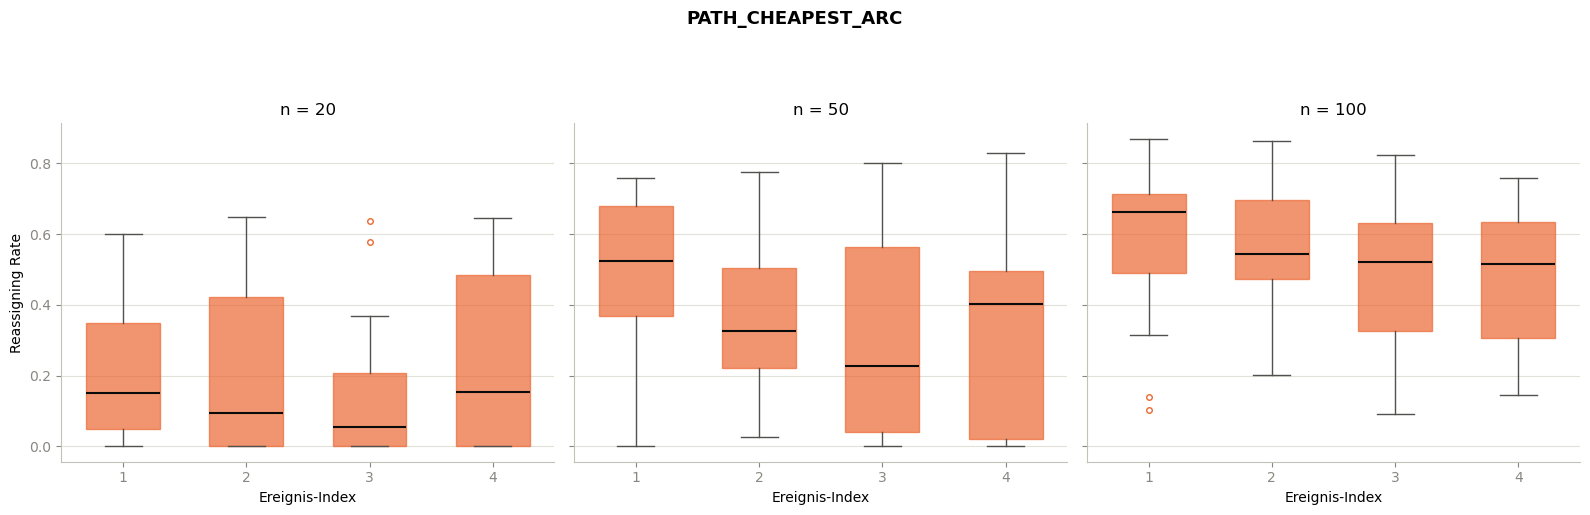

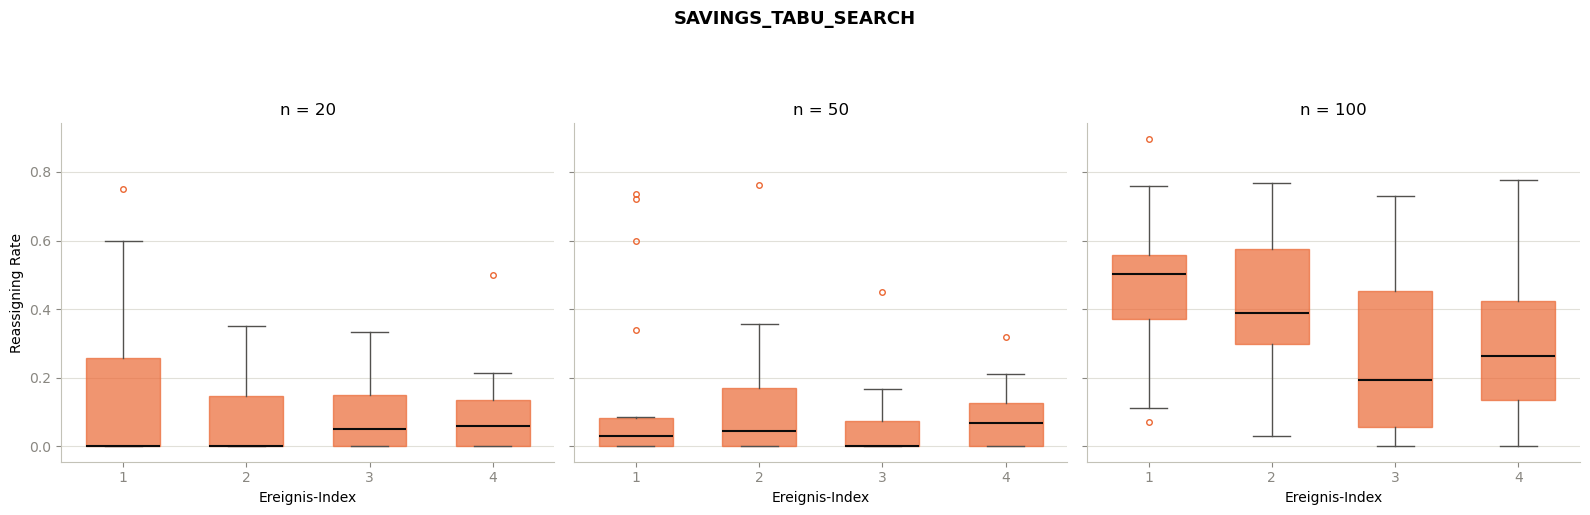

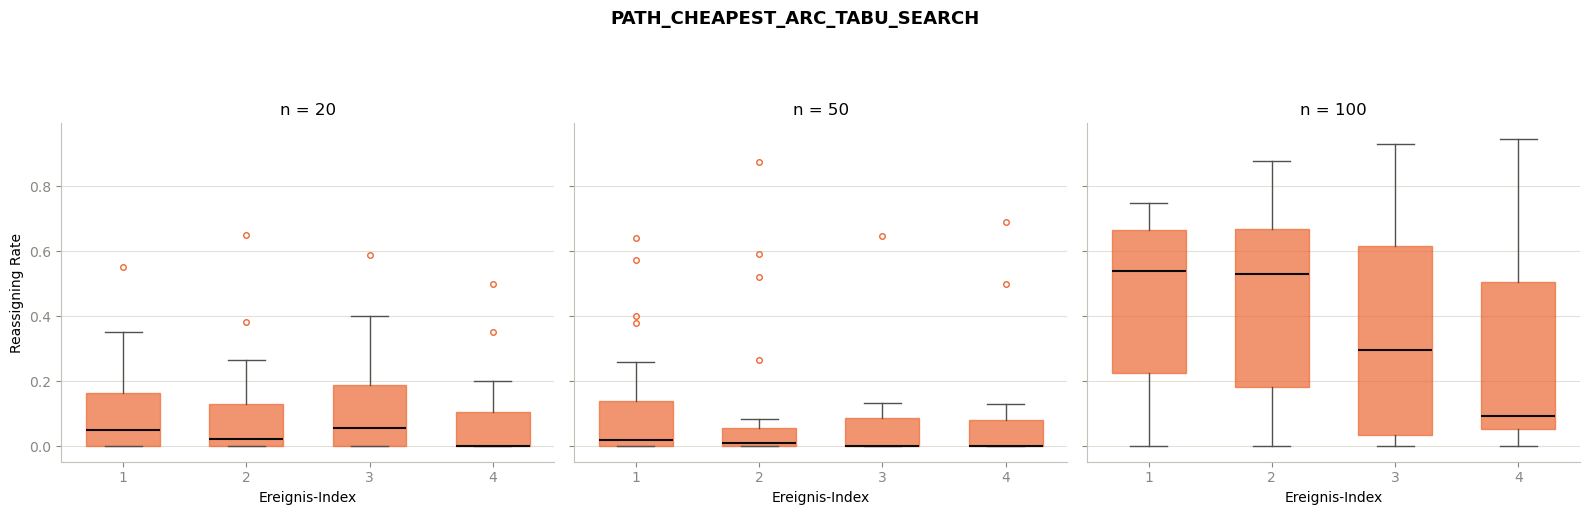

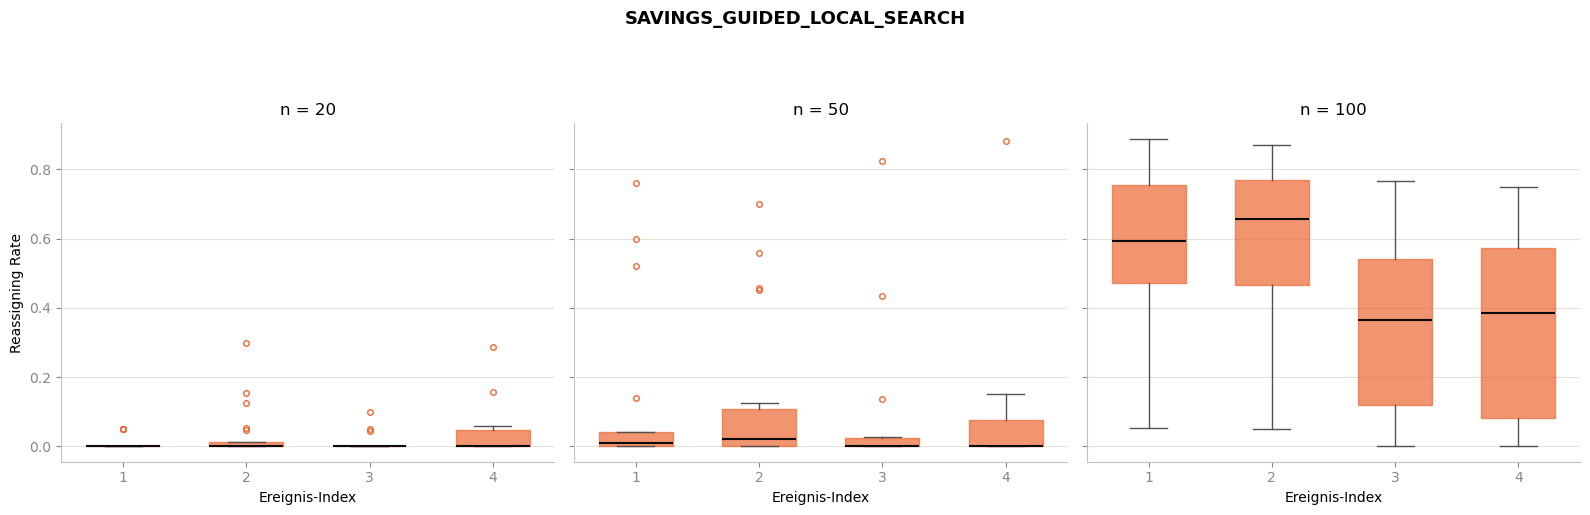

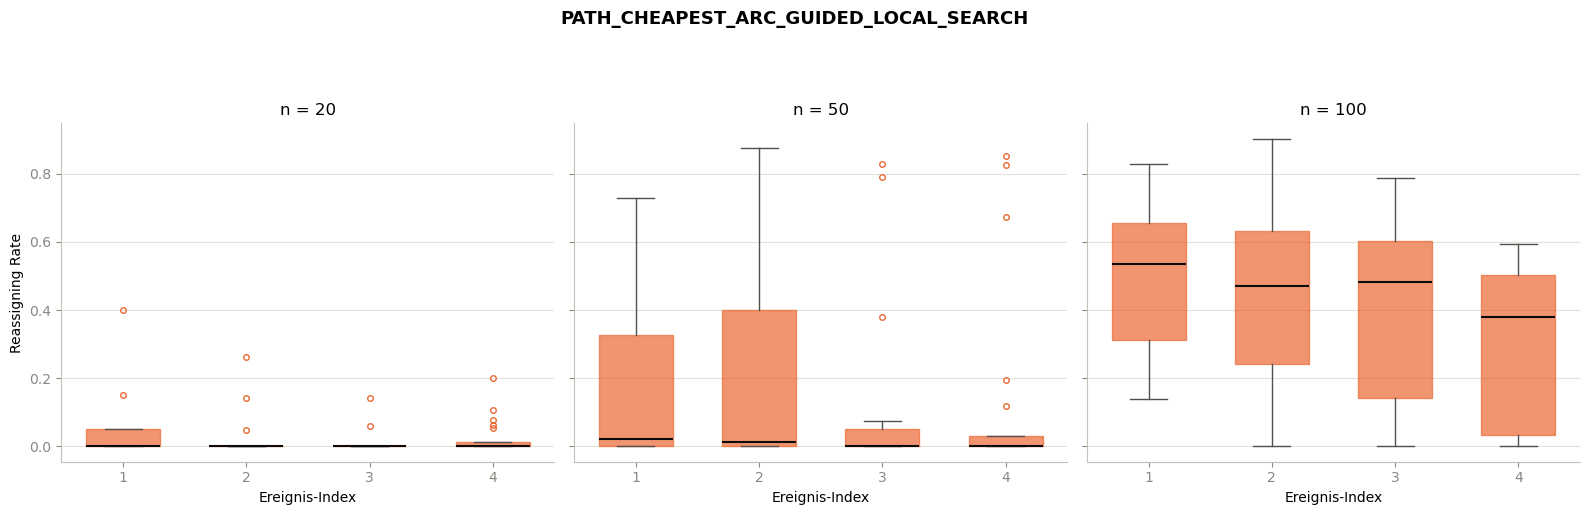

In [87]:
dynamic_runs = all_runs[all_runs["dynamic"]].copy()
dynamic_runs["event_index"] = dynamic_runs["reassigning_rates"].apply(lambda rr: list(range(1, len(rr) + 1)))

reassigning_df = (
    dynamic_runs[["strategy", "num_static_customers", "reassigning_rates", "event_index"]]
    .explode(["reassigning_rates", "event_index"])
    .rename(columns={"reassigning_rates": "reassigning_rate"})
)
reassigning_df["reassigning_rate"] = reassigning_df["reassigning_rate"].astype(float)
reassigning_df["event_index"] = reassigning_df["event_index"].astype(int)


def plot_reassigning_group(strategy):
    event_indices = [1, 2, 3, 4]
    x = np.arange(len(event_indices))

    fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

    for ax, n in zip(axes, COUNTS):
        subset = reassigning_df[
            (reassigning_df["strategy"] == strategy) & (reassigning_df["num_static_customers"] == n)
        ]
        data = [subset[subset["event_index"] == i]["reassigning_rate"] for i in event_indices]

        ax.boxplot(
            data,
            positions=x,
            widths=0.6,
            patch_artist=True,
            medianprops={"color": "#0b0b0b", "linewidth": 1.5},
            boxprops={"facecolor": colors["dynamic"], "edgecolor": colors["dynamic"], "alpha": 0.7},
            whiskerprops={"color": "#52514e"},
            capprops={"color": "#52514e"},
            flierprops={"markeredgecolor": colors["dynamic"], "markersize": 4},
        )

        ax.set_xticks(x)
        ax.set_xticklabels([str(i) for i in event_indices])
        ax.set_xlabel("Ereignis-Index")
        ax.set_title(f"n = {n}")
        ax.spines[["top", "right"]].set_visible(False)
        ax.spines[["left", "bottom"]].set_color("#c3c2b7")
        ax.tick_params(colors="#898781")
        ax.yaxis.grid(True, color="#e1e0d9", linewidth=0.8)
        ax.set_axisbelow(True)

    axes[0].set_ylabel("Reassigning Rate")

    fig.suptitle(strategy, y=1.02, fontsize=13, fontweight="bold")

    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()


for strategy in STRATEGIES:
    plot_reassigning_group(strategy)


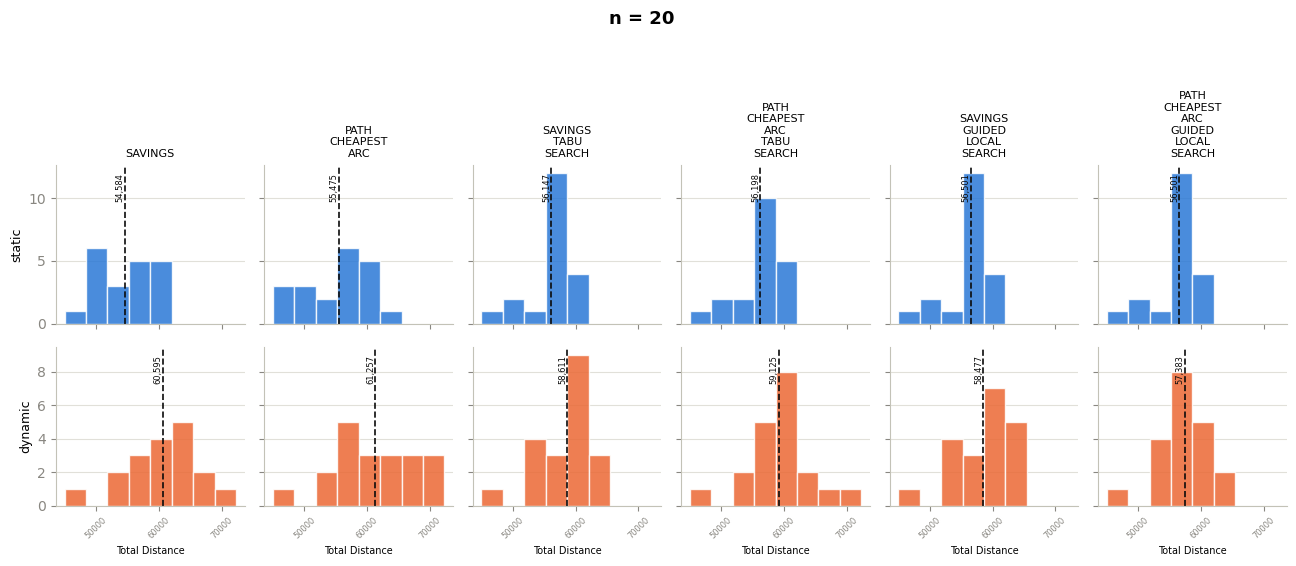

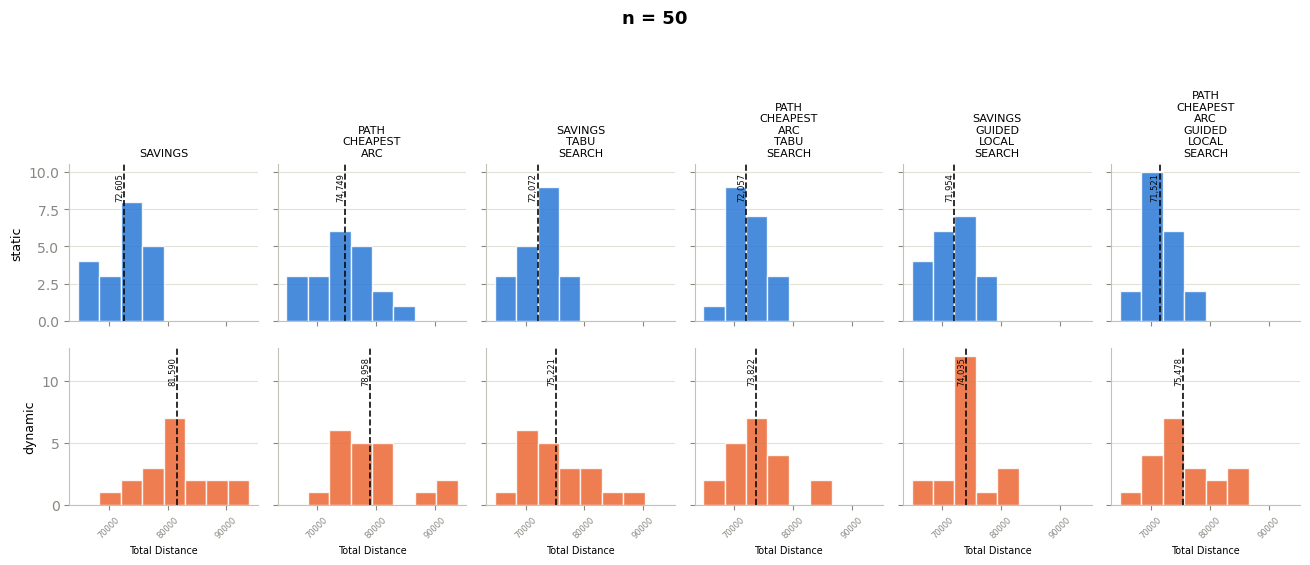

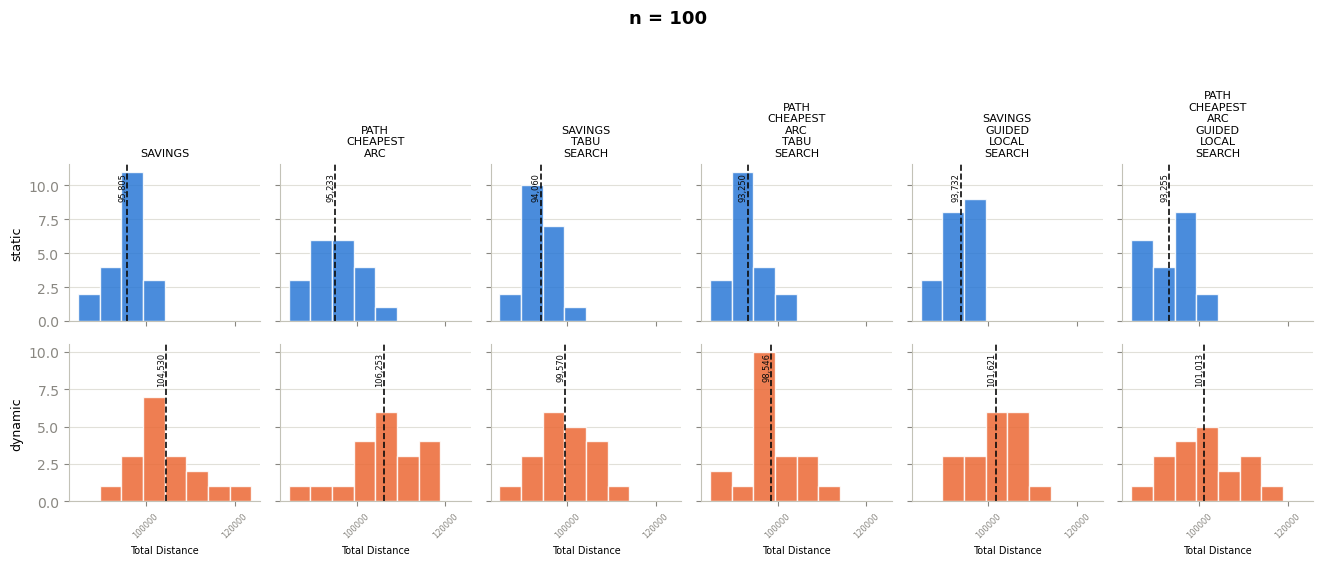

In [88]:
def plot_metric_histograms(data, value_col, xlabel, counts=COUNTS, bins=8, center=None, fmt="{:.2f}"):
    for n in counts:
        subset = data[data["num_static_customers"] == n]
        vmin, vmax = subset[value_col].min(), subset[value_col].max()
        bin_edges = np.linspace(vmin, vmax, bins + 1)

        fig, axes = plt.subplots(
            2, len(STRATEGIES), figsize=(2.2 * len(STRATEGIES), 5.5), sharex=True, sharey="row"
        )

        for col, strategy in enumerate(STRATEGIES):
            strat_subset = subset[subset["strategy"] == strategy]
            for row, (dynamic, kind) in enumerate(((False, "static"), (True, "dynamic"))):
                ax = axes[row, col]
                values = strat_subset[strat_subset["dynamic"] == dynamic][value_col]
                ax.hist(values, bins=bin_edges, color=colors[kind], edgecolor="white", alpha=0.85)
                if center is not None:
                    _annotate_center(ax, values, center=center, fmt=fmt)
                _style_axis(ax)
                if row == 0:
                    ax.set_title(strategy.replace("_", "\n"), fontsize=8)
                if col == 0:
                    ax.set_ylabel(kind, fontsize=9)
                if row == 1:
                    ax.set_xlabel(xlabel, fontsize=7)
                    ax.tick_params(axis="x", labelrotation=45, labelsize=6)

        fig.suptitle(f"n = {n}", y=1.02, fontsize=13, fontweight="bold")
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()


# bins bewusst klein: nur 20 Replikationen pro Zelle (strategy x static/dynamic x n)
plot_metric_histograms(all_runs, "total_distance", "Total Distance", center="mean", fmt="{:,.0f}")


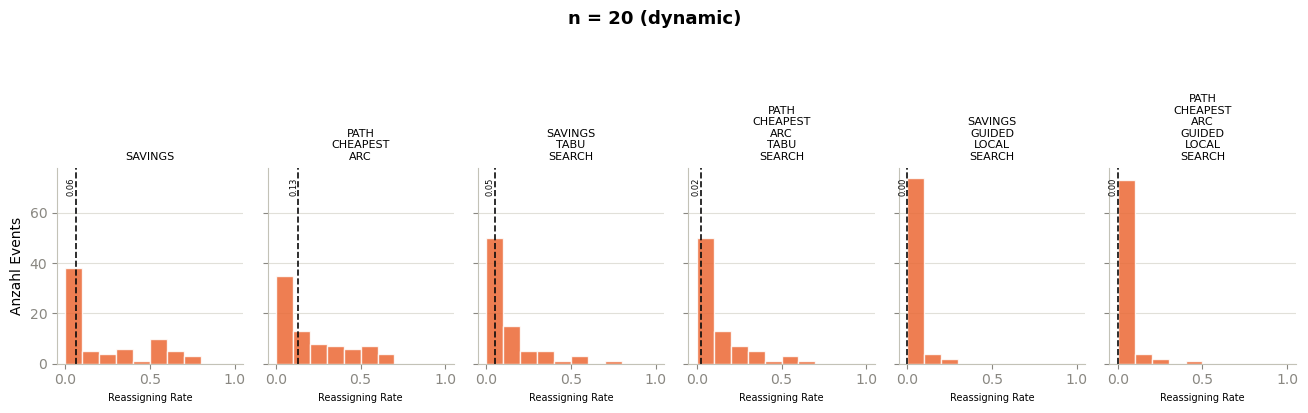

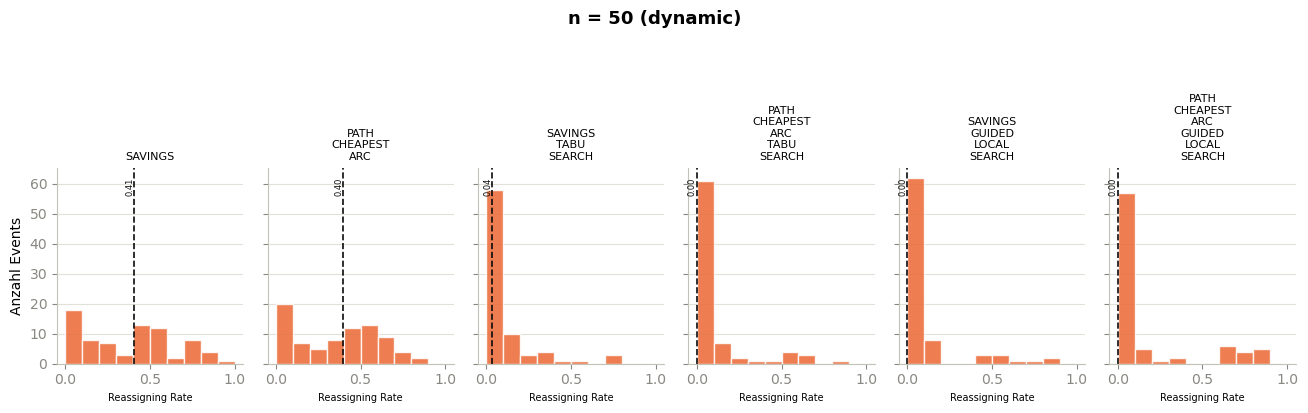

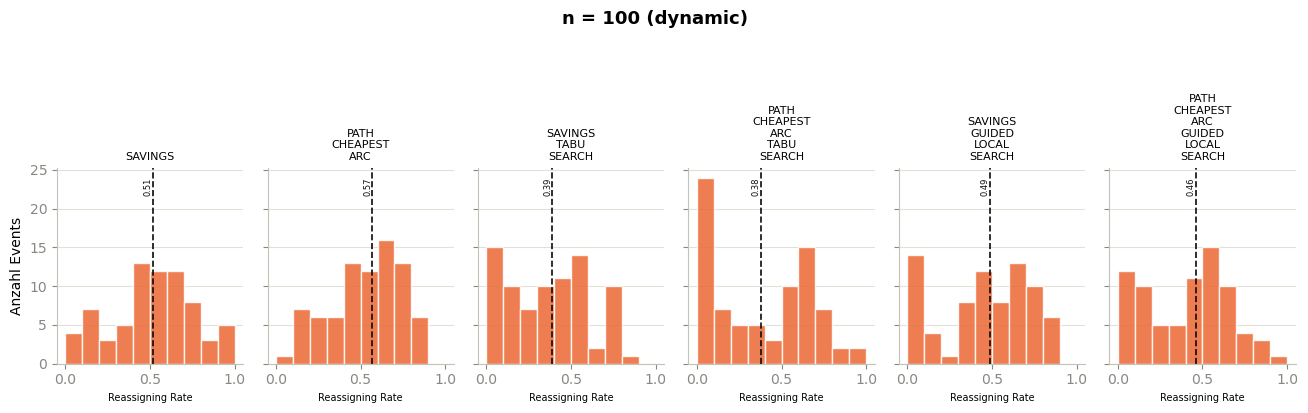

In [89]:
def plot_reassigning_histograms(counts=COUNTS, bins=10):
    bin_edges = np.linspace(0, 1, bins + 1)

    for n in counts:
        subset = reassigning_df[reassigning_df["num_static_customers"] == n]

        fig, axes = plt.subplots(1, len(STRATEGIES), figsize=(2.2 * len(STRATEGIES), 4), sharey=True)

        for ax, strategy in zip(axes, STRATEGIES):
            values = subset[subset["strategy"] == strategy]["reassigning_rate"]
            ax.hist(values, bins=bin_edges, color=colors["dynamic"], edgecolor="white", alpha=0.85)
            _annotate_center(ax, values, center="median", fmt="{:.2f}")
            ax.set_title(strategy.replace("_", "\n"), fontsize=8)
            ax.set_xlabel("Reassigning Rate", fontsize=7)
            _style_axis(ax)

        axes[0].set_ylabel("Anzahl Events")
        fig.suptitle(f"n = {n} (dynamic)", y=1.02, fontsize=13, fontweight="bold")
        plt.tight_layout(rect=[0, 0, 1, 0.93])
        plt.show()


plot_reassigning_histograms()


In [90]:
raw_frames = []
for strategy in STRATEGIES:
    for dynamic in (False, True):
        for n in COUNTS:
            kind = "dynamic" if dynamic else "static"
            df = read_jsonl(f"{strategy}/{strategy}_{kind}_{n}.jsonl")
            df["strategy"] = strategy
            df["dynamic"] = dynamic
            raw_frames.append(df)

raw_runs = pd.concat(raw_frames, ignore_index=True)

failed = ~raw_runs["all_orders_delivered"]
print(f"{failed.mean():.2%} der Versuche haben all_orders_delivered == False ({failed.sum()} von {len(raw_runs)})")


0.97% der Versuche haben all_orders_delivered == False (7 von 720)
